# Tarea: Algoritmo de Clustering DBSCAN

**Density-Based Spatial Clustering of Applications with Noise**

---

## Contenido

1. Concepto, fundamentos matemáticos, hiperparámetros, aplicaciones, ventajas y desventajas
2. Implementación en Python con `make_moons()` y `make_circles()`
3. Métricas de evaluación: internas (Davies–Bouldin, Calinski–Harabasz, Silhouette) y externas (ARI, NMI)
4. Comparación cualitativa y cuantitativa contra K-means
5. Aplicación de DBSCAN en dos problemas de elección libre

---

## 1. Concepto y fundamentos teóricos

### 1.1 ¿Qué es DBSCAN?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) fue propuesto por Ester, Kriegel, Sander y Xu en 1996. A diferencia de K-means —que asume clusters convexos y de tamaño similar—, DBSCAN ve a los **clusters como regiones de alta densidad de puntos separadas por regiones de baja densidad**. Esto le permite encontrar clusters de **forma arbitraria** y, simultáneamente, **identificar ruido (outliers)**.

### 1.2 Fundamentos matemáticos

DBSCAN se basa en dos hiperparámetros:

- $\varepsilon$ (`eps`): radio que define la vecindad de un punto.
- `min_samples` ($m$): número mínimo de puntos que debe haber en la vecindad para considerar a un punto como "central".

A partir de ellos se definen los siguientes conceptos:

**Vecindad-$\varepsilon$ de un punto $p$:**
$$N_\varepsilon(p) = \{ q \in D \mid d(p, q) \leq \varepsilon \}$$

donde $D$ es el conjunto de datos y $d(\cdot, \cdot)$ es una métrica de distancia (típicamente euclidiana).

**Clasificación de puntos:**

1. **Punto central (core point):** $p$ es central si $|N_\varepsilon(p)| \geq m$.
2. **Punto frontera (border point):** $p$ no es central, pero pertenece a $N_\varepsilon(q)$ para algún punto central $q$.
3. **Punto ruido (noise):** $p$ no es central ni frontera. En scikit-learn se etiqueta como `-1`.

**Alcanzabilidad por densidad (density-reachable):**

Un punto $q$ es **directamente alcanzable por densidad** desde $p$ si $p$ es central y $q \in N_\varepsilon(p)$. La relación se extiende transitivamente: $q$ es **alcanzable por densidad** desde $p$ si existe una cadena $p = p_1, p_2, \dots, p_n = q$ donde cada $p_{i+1}$ es directamente alcanzable desde $p_i$.

**Conexión por densidad (density-connected):**

Dos puntos $p$ y $q$ están conectados por densidad si existe un punto central $o$ tal que tanto $p$ como $q$ son alcanzables por densidad desde $o$.

**Definición formal de cluster:**

Un cluster $C$ es un subconjunto no vacío de $D$ que satisface:

1. **Maximidad:** $\forall p, q$, si $p \in C$ y $q$ es alcanzable por densidad desde $p$, entonces $q \in C$.
2. **Conectividad:** $\forall p, q \in C$, $p$ y $q$ están conectados por densidad.

### 1.3 Algoritmo (pseudocódigo)

```
DBSCAN(D, eps, min_samples):
    C = 0  # contador de clusters
    para cada punto p no visitado en D:
        marcar p como visitado
        N = vecindad_eps(p)
        si |N| < min_samples:
            etiquetar p como ruido (-1)
        sino:
            C = C + 1
            expandir_cluster(p, N, C, eps, min_samples)

expandir_cluster(p, N, C, eps, min_samples):
    asignar p al cluster C
    para cada punto q en N:
        si q no ha sido visitado:
            marcar q como visitado
            N' = vecindad_eps(q)
            si |N'| >= min_samples:
                N = N ∪ N'
        si q no pertenece a ningún cluster:
            asignar q al cluster C
```

### 1.4 Hiperparámetros

| Parámetro | Descripción | Cómo elegirlo |
|-----------|-------------|---------------|
| `eps` ($\varepsilon$) | Radio de la vecindad | Gráfico de distancia al k-ésimo vecino más cercano (k-distance plot): se busca el "codo". |
| `min_samples` ($m$) | Mínimo de puntos para ser central | Heurística: $m \geq d+1$, donde $d$ es la dimensionalidad. Para 2D: $m=4$ es común. Datos ruidosos requieren valores mayores. |
| `metric` | Métrica de distancia | Por defecto euclidiana; pueden usarse Manhattan, coseno, Mahalanobis, etc. |

### 1.5 Aplicaciones

- **Detección de anomalías**: fraude bancario, intrusiones en redes.
- **Segmentación de imágenes**: agrupar píxeles similares.
- **Análisis geoespacial**: identificación de zonas de actividad (crimen, comercio, sismos).
- **Bioinformática**: agrupamiento de expresión génica.
- **Análisis de redes sociales**: detección de comunidades.
- **Astronomía**: identificación de cúmulos estelares.

### 1.6 Ventajas

- ✅ No requiere especificar el número de clusters de antemano.
- ✅ Encuentra clusters de forma arbitraria (no solo convexos).
- ✅ Robusto frente a outliers (los identifica explícitamente).
- ✅ Determinista para los puntos centrales (los puntos frontera pueden depender del orden).
- ✅ Solo dos hiperparámetros principales.

### 1.7 Desventajas

- ❌ Sensibilidad a `eps` y `min_samples`: una mala elección produce malos resultados.
- ❌ **Densidad globalmente homogénea**: no maneja bien clusters con densidades muy diferentes (HDBSCAN soluciona esto).
- ❌ Sufre la **maldición de la dimensionalidad**: las distancias se vuelven menos discriminativas en alta dimensión.
- ❌ Complejidad: $O(n \log n)$ con índices espaciales (KD-tree, ball-tree); $O(n^2)$ en el peor caso.
- ❌ La asignación de puntos frontera puede depender del orden de procesamiento.

## Configuración inicial e importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.datasets import (
    make_moons, make_circles, make_blobs,
    load_iris, load_wine, fetch_openml
)
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


## 2. Implementación con `make_moons()` y `make_circles()`

Estos datasets son ideales para mostrar la fortaleza de DBSCAN: contienen clusters de **forma no convexa** que K-means no puede separar correctamente, mientras que DBSCAN sí lo hace fácilmente.

### 2.1 Generación de datos

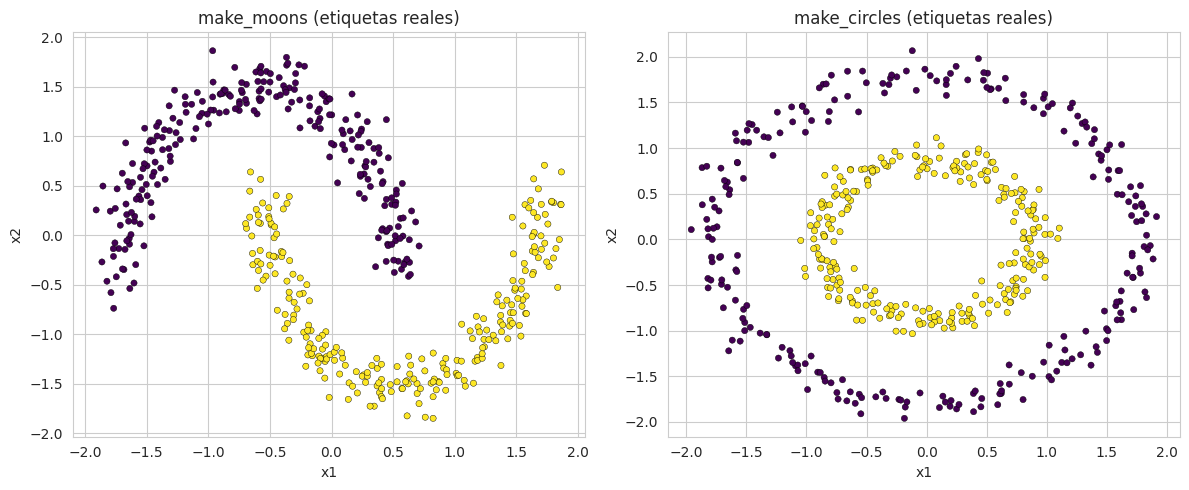

In [2]:
# Datasets sintéticos
n_samples = 500

X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.05, factor=0.5, random_state=RANDOM_STATE)

# Estandarización (importante para DBSCAN)
X_moons_s = StandardScaler().fit_transform(X_moons)
X_circles_s = StandardScaler().fit_transform(X_circles)

# Visualización inicial
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons_s[:, 0], X_moons_s[:, 1], c=y_moons, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[0].set_title('make_moons (etiquetas reales)')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

axes[1].scatter(X_circles_s[:, 0], X_circles_s[:, 1], c=y_circles, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[1].set_title('make_circles (etiquetas reales)')
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')
plt.tight_layout(); plt.show()

### 2.2 Selección de `eps` con el gráfico de k-distancias

Una heurística estándar para elegir `eps` es graficar la distancia al $k$-ésimo vecino más cercano (con $k = $ `min_samples`) ordenada de menor a mayor. El "codo" de la curva sugiere un buen valor de `eps`.

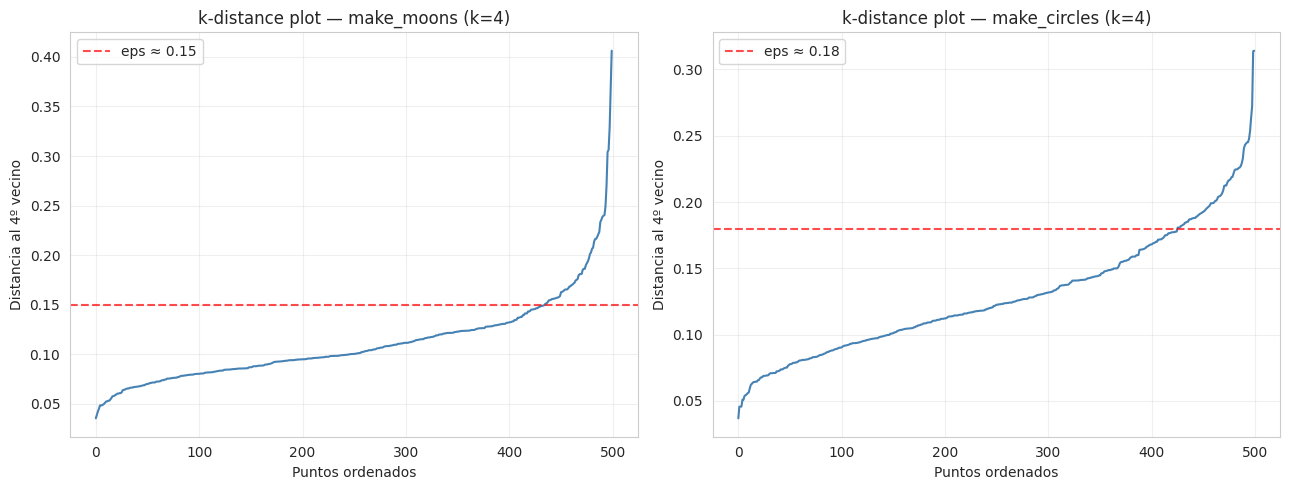

El 'codo' de la curva sugiere un buen valor de eps.
Para moons (estandarizado, noise=0.08), eps ≈ 0.18-0.22 funciona bien.
Para circles (anillos delgados), conviene un eps un poco mayor: ≈ 0.25.


In [3]:
def k_distance_plot(X, k=4, ax=None, title=''):
    """Grafica la distancia al k-ésimo vecino más cercano, ordenada."""
    nn = NearestNeighbors(n_neighbors=k+1).fit(X)  # +1 porque incluye el punto mismo
    distances, _ = nn.kneighbors(X)
    k_dist = np.sort(distances[:, k])  # k-ésima distancia (la mayor de los k vecinos)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(k_dist, color='steelblue')
    ax.set_xlabel('Puntos ordenados')
    ax.set_ylabel(f'Distancia al {k}º vecino')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return k_dist

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
k_distance_plot(X_moons_s, k=4, ax=axes[0], title='k-distance plot — make_moons (k=4)')
k_distance_plot(X_circles_s, k=4, ax=axes[1], title='k-distance plot — make_circles (k=4)')

# Líneas guía aproximadas
axes[0].axhline(0.15, color='red', ls='--', alpha=0.7, label='eps ≈ 0.15')
axes[1].axhline(0.18, color='red', ls='--', alpha=0.7, label='eps ≈ 0.18')
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

print("El 'codo' de la curva sugiere un buen valor de eps.")
print("Para moons (estandarizado, noise=0.08), eps ≈ 0.18-0.22 funciona bien.")
print("Para circles (anillos delgados), conviene un eps un poco mayor: ≈ 0.25.")

### 2.3 Aplicación de DBSCAN

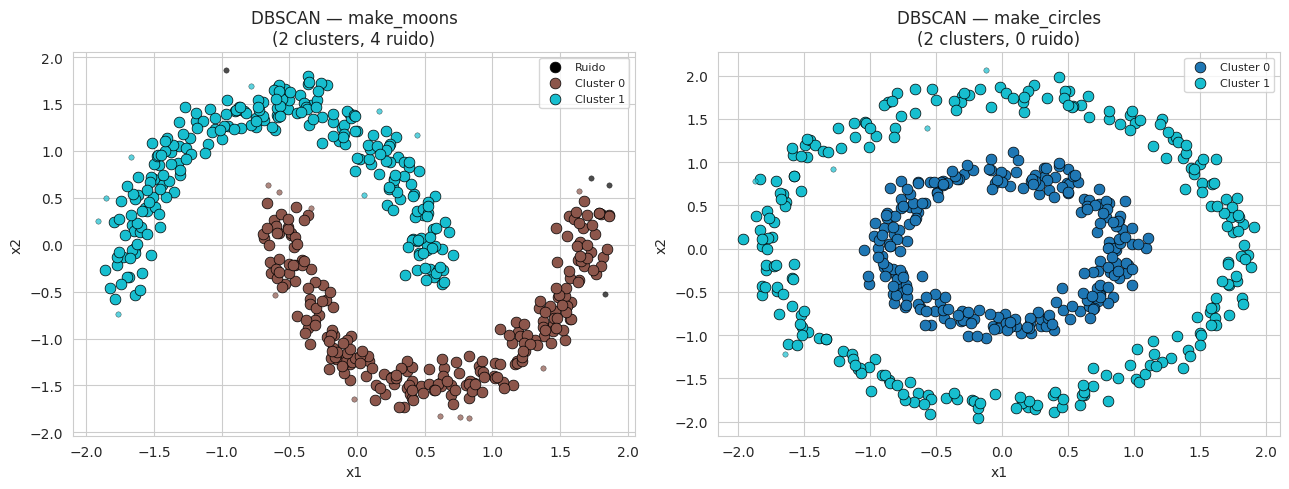

make_moons: 2 clusters detectados, 4 puntos como ruido, 478 puntos centrales.
make_circles: 2 clusters detectados, 0 puntos como ruido, 495 puntos centrales.


In [4]:
def visualize_dbscan(X, labels, core_mask, title, ax):
    """Visualiza puntos centrales, frontera y ruido."""
    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

    for label, color in zip(sorted(unique_labels), colors):
        if label == -1:
            color = [0, 0, 0, 1]  # ruido en negro
        class_mask = (labels == label)
        # Puntos centrales (más grandes)
        xy_core = X[class_mask & core_mask]
        ax.scatter(xy_core[:, 0], xy_core[:, 1], c=[color], s=60,
                   edgecolor='k', linewidth=0.5,
                   label=f'Cluster {label}' if label != -1 else 'Ruido')
        # Puntos frontera (más pequeños)
        xy_border = X[class_mask & ~core_mask]
        ax.scatter(xy_border[:, 0], xy_border[:, 1], c=[color], s=15,
                   edgecolor='k', linewidth=0.3, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(loc='best', fontsize=8)


# Ajuste de DBSCAN — usamos eps específico para cada dataset
# (los anillos de make_circles requieren eps un poco mayor)
db_moons = DBSCAN(eps=0.20, min_samples=5).fit(X_moons_s)
db_circles = DBSCAN(eps=0.25, min_samples=5).fit(X_circles_s)

# Máscara de puntos centrales
core_moons = np.zeros_like(db_moons.labels_, dtype=bool)
core_moons[db_moons.core_sample_indices_] = True

core_circles = np.zeros_like(db_circles.labels_, dtype=bool)
core_circles[db_circles.core_sample_indices_] = True

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
visualize_dbscan(X_moons_s, db_moons.labels_, core_moons,
                 f'DBSCAN — make_moons\n({len(set(db_moons.labels_)) - (1 if -1 in db_moons.labels_ else 0)} clusters, '
                 f'{(db_moons.labels_ == -1).sum()} ruido)', axes[0])
visualize_dbscan(X_circles_s, db_circles.labels_, core_circles,
                 f'DBSCAN — make_circles\n({len(set(db_circles.labels_)) - (1 if -1 in db_circles.labels_ else 0)} clusters, '
                 f'{(db_circles.labels_ == -1).sum()} ruido)', axes[1])
plt.tight_layout(); plt.show()

# Resumen
for nombre, db in [('make_moons', db_moons), ('make_circles', db_circles)]:
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = (db.labels_ == -1).sum()
    print(f"{nombre}: {n_clusters} clusters detectados, {n_noise} puntos como ruido, "
          f"{len(db.core_sample_indices_)} puntos centrales.")

### 2.4 Sensibilidad a los hiperparámetros

DBSCAN es muy sensible a `eps`. Veamos qué ocurre con valores demasiado pequeños o demasiado grandes.

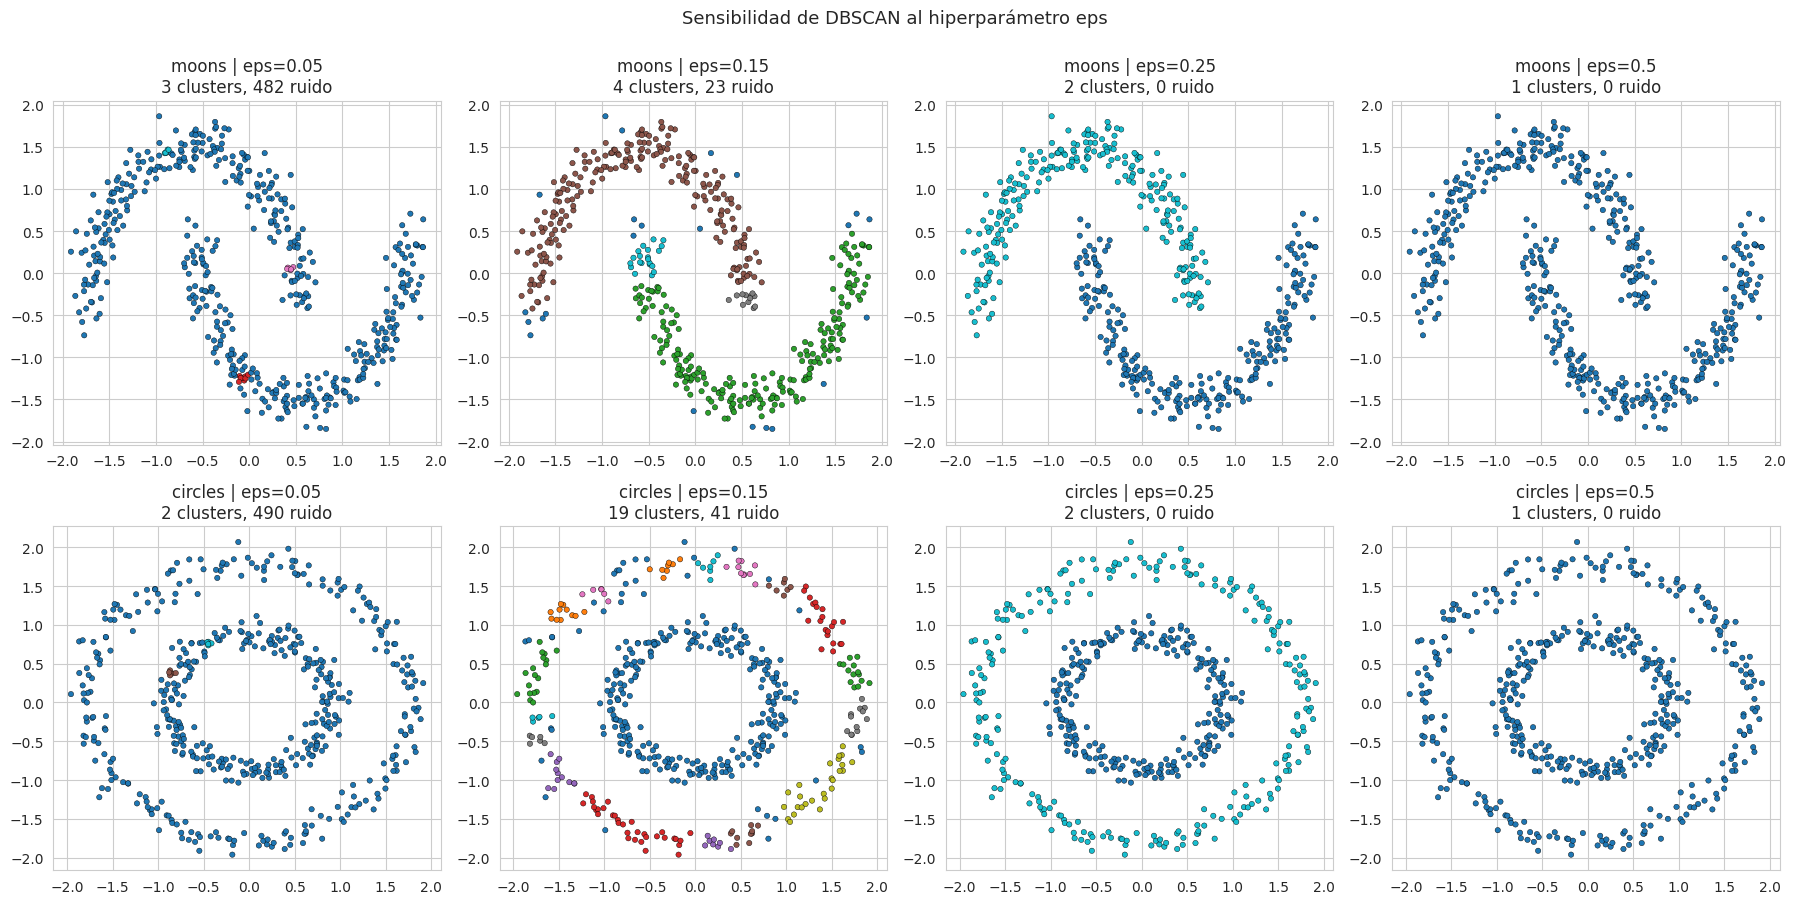

Observación: con eps muy pequeño todo se vuelve ruido;
con eps muy grande, todos los puntos se fusionan en un solo cluster.


In [5]:
eps_values = [0.05, 0.15, 0.25, 0.50]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for j, eps in enumerate(eps_values):
    # moons
    db = DBSCAN(eps=eps, min_samples=5).fit(X_moons_s)
    n_c = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_n = (db.labels_ == -1).sum()
    axes[0, j].scatter(X_moons_s[:, 0], X_moons_s[:, 1], c=db.labels_,
                       cmap='tab10', s=15, edgecolor='k', linewidth=0.3)
    axes[0, j].set_title(f'moons | eps={eps}\n{n_c} clusters, {n_n} ruido')

    # circles
    db = DBSCAN(eps=eps, min_samples=5).fit(X_circles_s)
    n_c = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_n = (db.labels_ == -1).sum()
    axes[1, j].scatter(X_circles_s[:, 0], X_circles_s[:, 1], c=db.labels_,
                       cmap='tab10', s=15, edgecolor='k', linewidth=0.3)
    axes[1, j].set_title(f'circles | eps={eps}\n{n_c} clusters, {n_n} ruido')

plt.suptitle('Sensibilidad de DBSCAN al hiperparámetro eps', fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

print("Observación: con eps muy pequeño todo se vuelve ruido;")
print("con eps muy grande, todos los puntos se fusionan en un solo cluster.")

## 3. Métricas de evaluación

### 3.1 Métricas internas

Las **métricas internas** evalúan la calidad del clustering **sin necesitar etiquetas verdaderas**. Se basan en propiedades de los datos y las asignaciones.

#### 3.1.1 Silhouette score

Mide qué tan similar es un punto a su propio cluster comparado con otros clusters. Para un punto $i$:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

donde:
- $a(i)$ es la distancia promedio de $i$ a los demás puntos de su cluster (cohesión).
- $b(i)$ es la distancia promedio de $i$ a los puntos del cluster más cercano que no es el suyo (separación).

El score global es el promedio de $s(i)$. **Rango**: $[-1, 1]$. Valores cercanos a 1 indican clustering bien definido; cercanos a 0, clusters solapados; negativos, asignación incorrecta.

#### 3.1.2 Davies–Bouldin score

Mide la similitud promedio entre cada cluster y su cluster más similar:

$$DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \frac{\sigma_i + \sigma_j}{d(c_i, c_j)}$$

donde $\sigma_i$ es la dispersión interna del cluster $i$ y $d(c_i, c_j)$ es la distancia entre centroides. **Rango**: $[0, \infty)$. **Cuanto menor, mejor** (clusters más compactos y separados).

#### 3.1.3 Calinski–Harabasz score (Variance Ratio Criterion)

Razón entre dispersión inter-cluster e intra-cluster:

$$CH = \frac{\text{tr}(B_k)}{\text{tr}(W_k)} \cdot \frac{n - k}{k - 1}$$

donde $B_k$ es la matriz de dispersión entre clusters y $W_k$ la matriz de dispersión intra-cluster. **Rango**: $[0, \infty)$. **Cuanto mayor, mejor**.

### 3.2 Métricas externas

Las **métricas externas** comparan las etiquetas predichas contra las etiquetas verdaderas (ground truth).

#### 3.2.1 Adjusted Rand Index (ARI)

Considera todas las parejas de puntos y mide si están en el mismo cluster en ambas asignaciones. Sea:
- $a$ = pares en el mismo cluster en C (verdadero) y K (predicho)
- $b$ = pares en clusters diferentes en C y K

El **Rand Index** sin ajustar es:
$$RI = \frac{a + b}{\binom{n}{2}}$$

El **ARI** corrige por azar:
$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

**Rango**: $[-0.5, 1]$. ARI = 1 es coincidencia perfecta; ARI ≈ 0 corresponde a etiquetado aleatorio; valores negativos son peores que aleatorio.

#### 3.2.2 Normalized Mutual Information (NMI)

Información mutua normalizada entre las dos asignaciones de etiquetas. Dada la entropía $H(\cdot)$ y la información mutua $\text{MI}(U, V)$:

$$\text{NMI}(U, V) = \frac{\text{MI}(U, V)}{\text{mean}(H(U), H(V))}$$

donde:
$$\text{MI}(U, V) = \sum_{i=1}^{|U|}\sum_{j=1}^{|V|} P(i, j) \log\frac{P(i, j)}{P(i)P'(j)}$$

**Rango**: $[0, 1]$. NMI = 1 es coincidencia perfecta. La variante **AMI (Adjusted MI)** corrige por azar.

### 3.3 Manejo del ruido en DBSCAN

> **Importante:** DBSCAN puede etiquetar puntos como ruido (`-1`). Para calcular métricas internas (que requieren clusters), filtramos los puntos de ruido. Para métricas externas, podemos optar por (a) tratar `-1` como un cluster más, o (b) excluir esos puntos. En este trabajo reportamos las dos posibilidades cuando es relevante.

In [6]:
def evaluar_clustering(X, labels, y_true=None, nombre=''):
    """Calcula métricas internas y externas (si hay y_true)."""
    resultados = {'algoritmo': nombre}

    # Filtrar ruido para métricas internas
    mask = labels != -1
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    n_noise = (~mask).sum()
    resultados['n_clusters'] = n_clusters
    resultados['n_ruido'] = int(n_noise)

    # Métricas internas (necesitan al menos 2 clusters)
    if n_clusters >= 2:
        resultados['silhouette']         = silhouette_score(X[mask], labels[mask])
        resultados['davies_bouldin']     = davies_bouldin_score(X[mask], labels[mask])
        resultados['calinski_harabasz']  = calinski_harabasz_score(X[mask], labels[mask])
    else:
        resultados['silhouette'] = np.nan
        resultados['davies_bouldin'] = np.nan
        resultados['calinski_harabasz'] = np.nan

    # Métricas externas
    if y_true is not None:
        resultados['ARI'] = adjusted_rand_score(y_true, labels)
        resultados['NMI'] = normalized_mutual_info_score(y_true, labels)

    return resultados


# Evaluar DBSCAN en moons y circles
resultados_dbscan = []
resultados_dbscan.append(evaluar_clustering(X_moons_s, db_moons.labels_, y_moons, 'DBSCAN — moons'))
resultados_dbscan.append(evaluar_clustering(X_circles_s, db_circles.labels_, y_circles, 'DBSCAN — circles'))

df_eval = pd.DataFrame(resultados_dbscan)
print("Evaluación de DBSCAN:")
print(df_eval.to_string(index=False))

Evaluación de DBSCAN:
       algoritmo  n_clusters  n_ruido  silhouette  davies_bouldin  calinski_harabasz     ARI      NMI
  DBSCAN — moons           2        4    0.384742        1.020270         430.818844 0.98408 0.964943
DBSCAN — circles           2        0    0.112602      220.366847           0.009185 1.00000 1.000000


## 4. Comparación contra K-means

K-means asume que los clusters son **convexos e isotrópicos** (esféricos). En datasets como `make_moons` y `make_circles`, esa suposición falla y el resultado es claramente incorrecto. Comparamos cualitativa y cuantitativamente.

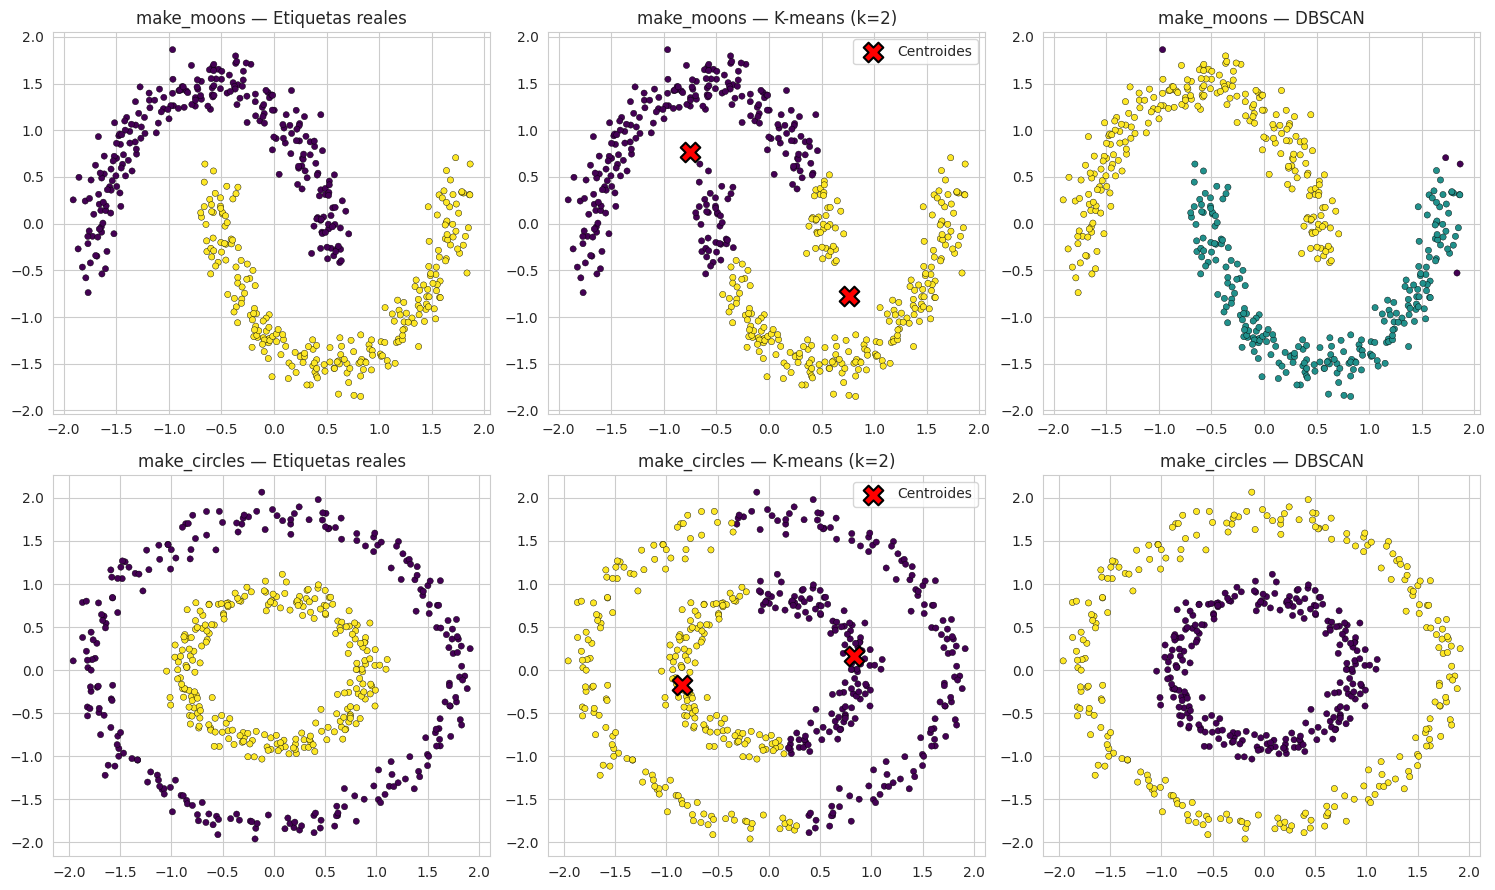

In [7]:
# K-means en ambos datasets
km_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_moons_s)
km_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_circles_s)

# Visualización comparativa
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Fila 1: moons
axes[0, 0].scatter(X_moons_s[:, 0], X_moons_s[:, 1], c=y_moons, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[0, 0].set_title('make_moons — Etiquetas reales')

axes[0, 1].scatter(X_moons_s[:, 0], X_moons_s[:, 1], c=km_moons.labels_, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[0, 1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
                   c='red', marker='X', s=200, edgecolor='black', linewidth=1.5, label='Centroides')
axes[0, 1].set_title('make_moons — K-means (k=2)')
axes[0, 1].legend()

axes[0, 2].scatter(X_moons_s[:, 0], X_moons_s[:, 1], c=db_moons.labels_, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[0, 2].set_title('make_moons — DBSCAN')

# Fila 2: circles
axes[1, 0].scatter(X_circles_s[:, 0], X_circles_s[:, 1], c=y_circles, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[1, 0].set_title('make_circles — Etiquetas reales')

axes[1, 1].scatter(X_circles_s[:, 0], X_circles_s[:, 1], c=km_circles.labels_, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[1, 1].scatter(km_circles.cluster_centers_[:, 0], km_circles.cluster_centers_[:, 1],
                   c='red', marker='X', s=200, edgecolor='black', linewidth=1.5, label='Centroides')
axes[1, 1].set_title('make_circles — K-means (k=2)')
axes[1, 1].legend()

axes[1, 2].scatter(X_circles_s[:, 0], X_circles_s[:, 1], c=db_circles.labels_, cmap='viridis', s=20, edgecolor='k', linewidth=0.3)
axes[1, 2].set_title('make_circles — DBSCAN')

plt.tight_layout(); plt.show()

### 4.1 Comparación cuantitativa

In [8]:
# Tabla comparativa
todos = []
todos.append(evaluar_clustering(X_moons_s, db_moons.labels_, y_moons, 'DBSCAN — moons'))
todos.append(evaluar_clustering(X_moons_s, km_moons.labels_, y_moons, 'K-means — moons'))
todos.append(evaluar_clustering(X_circles_s, db_circles.labels_, y_circles, 'DBSCAN — circles'))
todos.append(evaluar_clustering(X_circles_s, km_circles.labels_, y_circles, 'K-means — circles'))

df_comp = pd.DataFrame(todos)
df_comp = df_comp.round(4)
print("Comparación cuantitativa DBSCAN vs K-means:\n")
print(df_comp.to_string(index=False))

print()
print("⚠️ NOTA IMPORTANTE — Métricas internas en clusters no convexos:")
print("En 'circles', DBSCAN obtiene ARI=1.0 (clustering perfecto) pero peor Silhouette")
print("y Davies-Bouldin que K-means. Esto NO significa que K-means sea mejor: las métricas")
print("internas (Silhouette, DB, CH) asumen clusters convexos y son engañosas para")
print("clusters con forma de anillo. Para datos no convexos, las métricas externas (ARI, NMI)")
print("son mucho más confiables si se dispone de ground truth.")

Comparación cuantitativa DBSCAN vs K-means:

        algoritmo  n_clusters  n_ruido  silhouette  davies_bouldin  calinski_harabasz     ARI    NMI
   DBSCAN — moons           2        4      0.3847          1.0203           430.8188  0.9841 0.9649
  K-means — moons           2        0      0.4932          0.8132           690.2079  0.4451 0.3515
 DBSCAN — circles           2        0      0.1126        220.3668             0.0092  1.0000 1.0000
K-means — circles           2        0      0.3531          1.1825           287.0803 -0.0020 0.0000

⚠️ NOTA IMPORTANTE — Métricas internas en clusters no convexos:
En 'circles', DBSCAN obtiene ARI=1.0 (clustering perfecto) pero peor Silhouette
y Davies-Bouldin que K-means. Esto NO significa que K-means sea mejor: las métricas
internas (Silhouette, DB, CH) asumen clusters convexos y son engañosas para
clusters con forma de anillo. Para datos no convexos, las métricas externas (ARI, NMI)
son mucho más confiables si se dispone de ground truth.


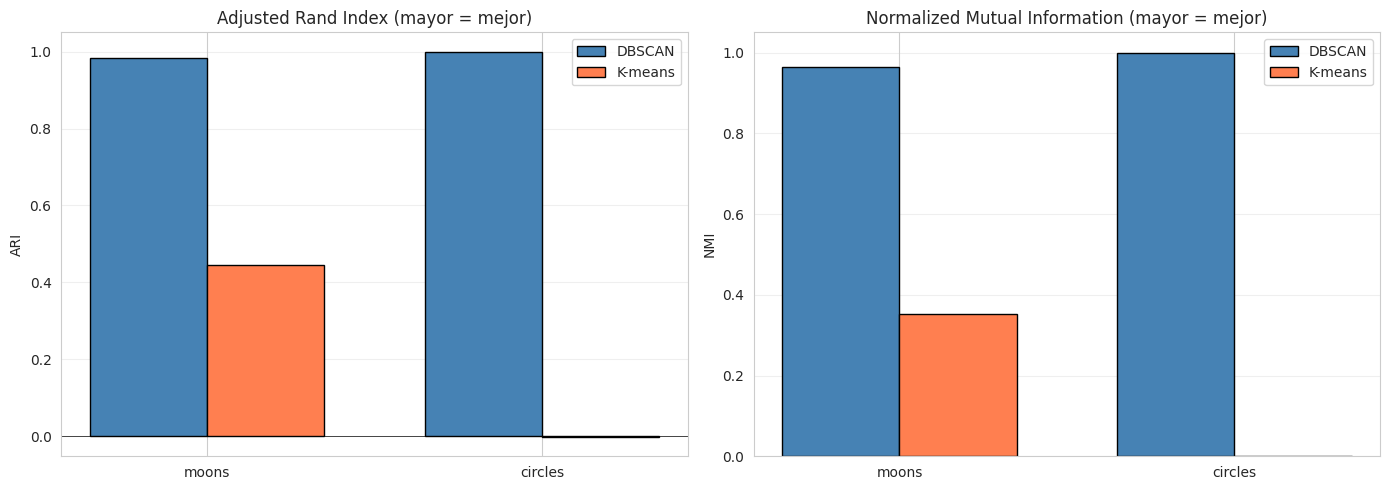

In [9]:
# Visualización de las métricas comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = ['moons', 'circles']
metricas_externas = ['ARI', 'NMI']

# ARI y NMI
x = np.arange(len(datasets))
width = 0.35
ari_db = [df_comp[df_comp.algoritmo == f'DBSCAN — {d}']['ARI'].values[0] for d in datasets]
ari_km = [df_comp[df_comp.algoritmo == f'K-means — {d}']['ARI'].values[0] for d in datasets]
nmi_db = [df_comp[df_comp.algoritmo == f'DBSCAN — {d}']['NMI'].values[0] for d in datasets]
nmi_km = [df_comp[df_comp.algoritmo == f'K-means — {d}']['NMI'].values[0] for d in datasets]

axes[0].bar(x - width/2, ari_db, width, label='DBSCAN', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, ari_km, width, label='K-means', color='coral', edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(datasets)
axes[0].set_ylabel('ARI'); axes[0].set_title('Adjusted Rand Index (mayor = mejor)')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0, color='black', lw=0.5)

axes[1].bar(x - width/2, nmi_db, width, label='DBSCAN', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, nmi_km, width, label='K-means', color='coral', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(datasets)
axes[1].set_ylabel('NMI'); axes[1].set_title('Normalized Mutual Information (mayor = mejor)')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

### 4.2 Análisis cualitativo

| Aspecto | DBSCAN | K-means |
|---------|--------|---------|
| **Forma de clusters** | Cualquier forma | Solo convexa/esférica |
| **Número de clusters** | Lo descubre | Debe especificarse |
| **Outliers** | Los detecta como ruido | Los asigna forzosamente a un cluster |
| **Sensibilidad a inicialización** | Determinista para puntos centrales | Dependiente de inicialización (k-means++ ayuda) |
| **Hiperparámetros** | `eps`, `min_samples` | `n_clusters` |
| **Complejidad** | $O(n \log n)$ con índices | $O(nki)$ |
| **Escalabilidad** | Buena con índices espaciales | Excelente |
| **`make_moons` / `make_circles`** | Recupera la estructura real | Falla: corta los datos por la mitad |

**Conclusión:** En datos con estructura no convexa, DBSCAN es claramente superior. K-means seguirá siendo preferible cuando los clusters son aproximadamente esféricos y se conoce el número $k$.

## 5. Aplicaciones de DBSCAN en problemas reales

Aplicamos DBSCAN a dos problemas distintos para mostrar su versatilidad:

1. **Iris dataset**: dataset clásico de flores con 4 atributos numéricos.
2. **Detección de outliers en datos sintéticos no convexos con ruido**: caso de uso clásico de DBSCAN como detector de anomalías.

### 5.1 Aplicación 1: Iris dataset

El dataset Iris contiene 150 muestras de flores de iris pertenecientes a 3 especies. Tiene 4 atributos: longitud y ancho de sépalo y pétalo. Veamos si DBSCAN encuentra estructura coherente con las especies.

Iris dataset: 150 muestras, 4 atributos, 3 clases
Clases: ['setosa' 'versicolor' 'virginica']


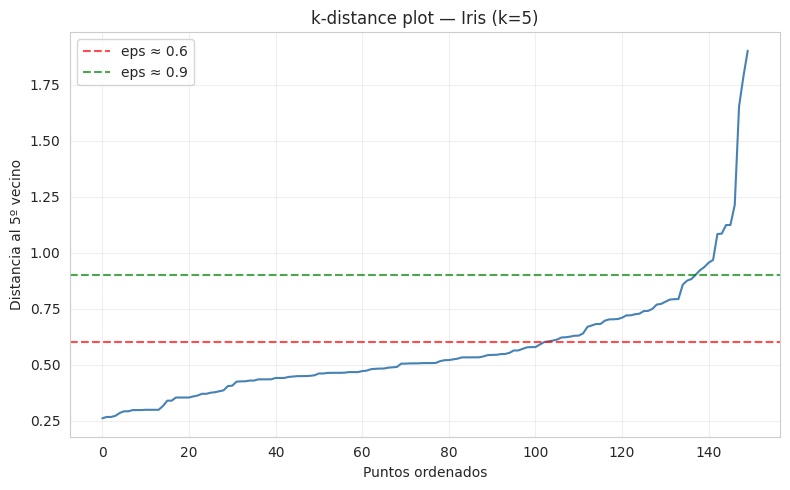

In [10]:
# Cargar Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
nombres_iris = iris.target_names

print(f"Iris dataset: {X_iris.shape[0]} muestras, {X_iris.shape[1]} atributos, {len(set(y_iris))} clases")
print(f"Clases: {nombres_iris}")

# Estandarización
X_iris_s = StandardScaler().fit_transform(X_iris)

# k-distance plot para elegir eps
fig, ax = plt.subplots(figsize=(8, 5))
k_distance_plot(X_iris_s, k=5, ax=ax, title='k-distance plot — Iris (k=5)')
ax.axhline(0.6, color='red', ls='--', alpha=0.7, label='eps ≈ 0.6')
ax.axhline(0.9, color='green', ls='--', alpha=0.7, label='eps ≈ 0.9')
ax.legend()
plt.tight_layout(); plt.show()

eps=0.5: 2 clusters,  34 ruido, ARI=0.442
eps=0.6: 2 clusters,  26 ruido, ARI=0.471
eps=0.7: 2 clusters,   6 ruido, ARI=0.540
eps=0.8: 2 clusters,   4 ruido, ARI=0.552
eps=0.9: 2 clusters,   4 ruido, ARI=0.552
eps=1.0: 2 clusters,   3 ruido, ARI=0.554


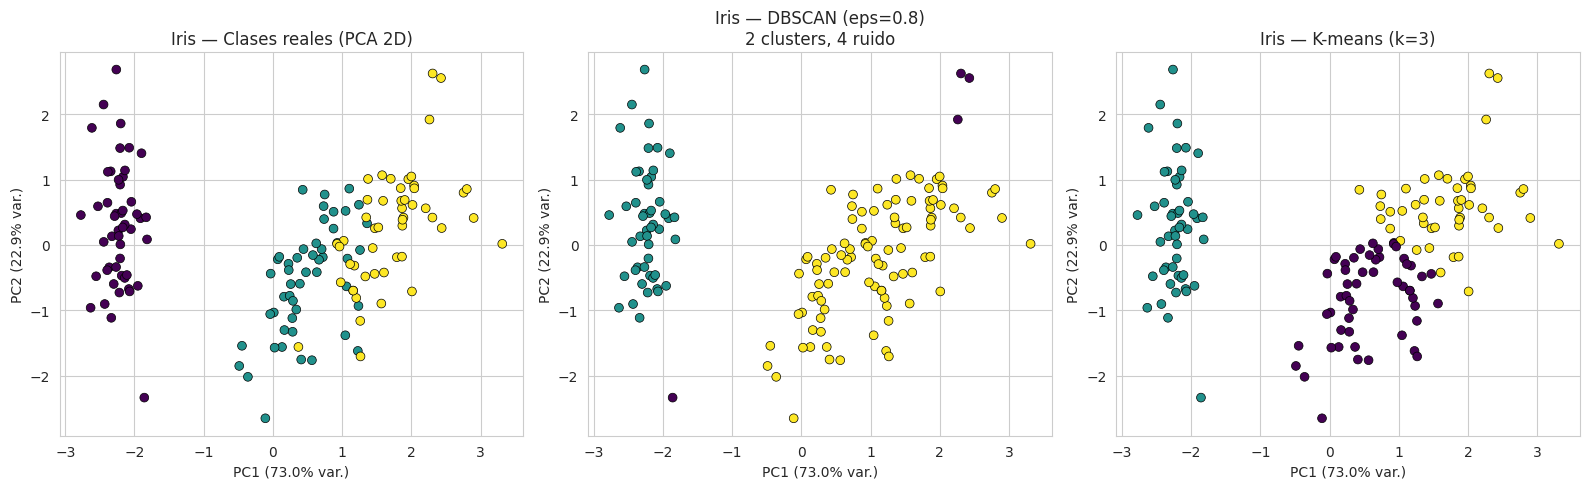

In [11]:
# Probar varios eps
mejor = None
for eps in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_iris_s)
    n_c = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_n = (db.labels_ == -1).sum()
    ari = adjusted_rand_score(y_iris, db.labels_)
    print(f"eps={eps}: {n_c} clusters, {n_n:3d} ruido, ARI={ari:.3f}")

# Aplicar DBSCAN con eps razonable
db_iris = DBSCAN(eps=0.8, min_samples=5).fit(X_iris_s)
km_iris = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X_iris_s)

# Visualizar en 2D usando PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_iris_2d = pca.fit_transform(X_iris_s)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=y_iris, cmap='viridis',
                s=40, edgecolor='k', linewidth=0.5)
axes[0].set_title('Iris — Clases reales (PCA 2D)')

axes[1].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=db_iris.labels_, cmap='viridis',
                s=40, edgecolor='k', linewidth=0.5)
axes[1].set_title(f'Iris — DBSCAN (eps=0.8)\n{len(set(db_iris.labels_)) - (1 if -1 in db_iris.labels_ else 0)} clusters, '
                  f'{(db_iris.labels_ == -1).sum()} ruido')

axes[2].scatter(X_iris_2d[:, 0], X_iris_2d[:, 1], c=km_iris.labels_, cmap='viridis',
                s=40, edgecolor='k', linewidth=0.5)
axes[2].set_title('Iris — K-means (k=3)')

for ax in axes:
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
plt.tight_layout(); plt.show()

In [12]:
# Evaluación cuantitativa Iris
res_iris = [
    evaluar_clustering(X_iris_s, db_iris.labels_, y_iris, 'DBSCAN — Iris'),
    evaluar_clustering(X_iris_s, km_iris.labels_, y_iris, 'K-means — Iris'),
]
df_iris = pd.DataFrame(res_iris).round(4)
print("Iris dataset — Evaluación:\n")
print(df_iris.to_string(index=False))

print("\nObservaciones:")
print("- En Iris, K-means logra un ARI mayor porque las clases son aproximadamente convexas en el espacio.")
print("- DBSCAN con frecuencia une 'versicolor' y 'virginica' en un mismo cluster porque sus densidades")
print("  no están claramente separadas, mostrando una limitación del algoritmo cuando la densidad varía.")

Iris dataset — Evaluación:

     algoritmo  n_clusters  n_ruido  silhouette  davies_bouldin  calinski_harabasz    ARI    NMI
 DBSCAN — Iris           2        4      0.5979          0.5688           277.6510 0.5518 0.6900
K-means — Iris           3        0      0.4599          0.8336           241.9044 0.6201 0.6595

Observaciones:
- En Iris, K-means logra un ARI mayor porque las clases son aproximadamente convexas en el espacio.
- DBSCAN con frecuencia une 'versicolor' y 'virginica' en un mismo cluster porque sus densidades
  no están claramente separadas, mostrando una limitación del algoritmo cuando la densidad varía.


### 5.2 Aplicación 2: Detección de outliers en datos con estructura no convexa

Una de las **fortalezas distintivas de DBSCAN es identificar outliers**. Generamos un dataset con dos clusters de forma compleja (lunas) y añadimos ruido aleatorio uniforme. DBSCAN debe identificar los puntos anómalos sin reglas explícitas.

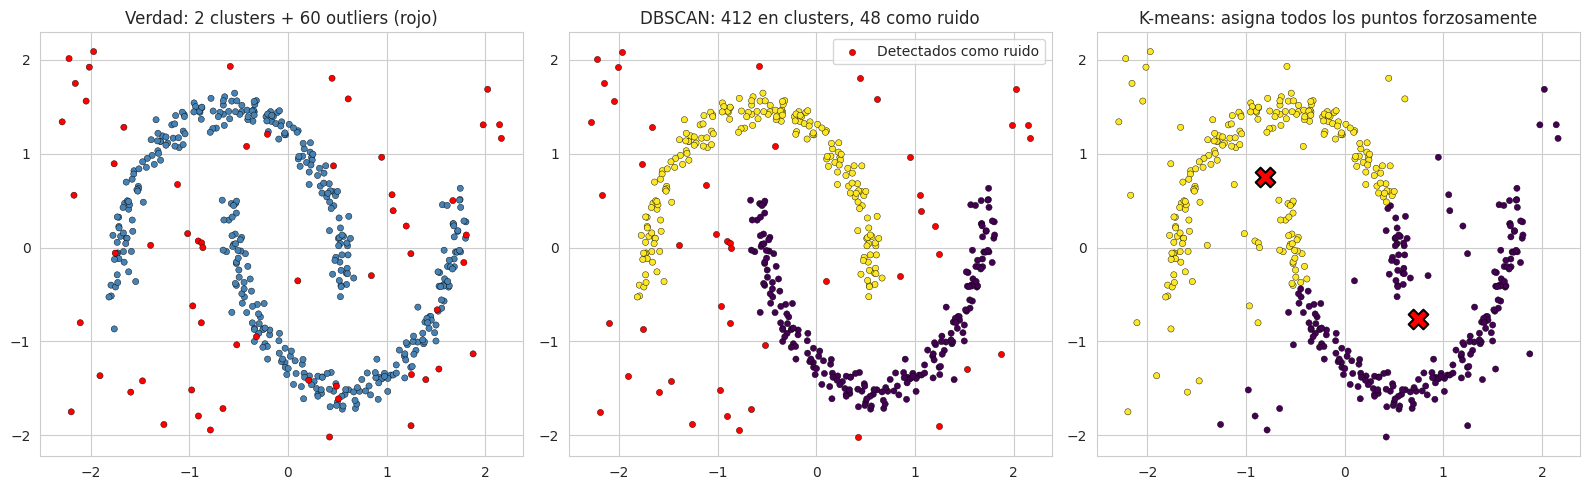

In [13]:
# Generar lunas con outliers añadidos
np.random.seed(RANDOM_STATE)
X_clean, y_clean = make_moons(n_samples=400, noise=0.05, random_state=RANDOM_STATE)
X_clean = StandardScaler().fit_transform(X_clean)

# Añadir 60 outliers uniformes
n_outliers = 60
outliers = np.random.uniform(low=X_clean.min(axis=0) - 0.5,
                              high=X_clean.max(axis=0) + 0.5,
                              size=(n_outliers, 2))
X_anom = np.vstack([X_clean, outliers])
y_anom = np.concatenate([y_clean, np.full(n_outliers, -1)])  # -1 marca verdaderos outliers

# Aplicar DBSCAN
db_anom = DBSCAN(eps=0.18, min_samples=5).fit(X_anom)
km_anom = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_anom)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Verdad
colors_true = np.where(y_anom == -1, 'red', 'steelblue')
axes[0].scatter(X_anom[:, 0], X_anom[:, 1], c=colors_true, s=20, edgecolor='k', linewidth=0.3)
axes[0].set_title(f'Verdad: 2 clusters + {n_outliers} outliers (rojo)')

# DBSCAN
mask_noise = db_anom.labels_ == -1
axes[1].scatter(X_anom[~mask_noise, 0], X_anom[~mask_noise, 1],
                c=db_anom.labels_[~mask_noise], cmap='viridis',
                s=20, edgecolor='k', linewidth=0.3)
axes[1].scatter(X_anom[mask_noise, 0], X_anom[mask_noise, 1],
                c='red', s=20, edgecolor='k', linewidth=0.3, label='Detectados como ruido')
axes[1].set_title(f'DBSCAN: {(db_anom.labels_ != -1).sum()} en clusters, '
                  f'{mask_noise.sum()} como ruido')
axes[1].legend()

# K-means (no detecta outliers)
axes[2].scatter(X_anom[:, 0], X_anom[:, 1], c=km_anom.labels_, cmap='viridis',
                s=20, edgecolor='k', linewidth=0.3)
axes[2].scatter(km_anom.cluster_centers_[:, 0], km_anom.cluster_centers_[:, 1],
                c='red', marker='X', s=200, edgecolor='black', linewidth=1.5)
axes[2].set_title('K-means: asigna todos los puntos forzosamente')

plt.tight_layout(); plt.show()

Detección de outliers con DBSCAN:
  Verdaderos positivos (outliers detectados): 47
  Falsos positivos (puntos normales marcados como outliers): 1
  Falsos negativos (outliers no detectados): 13
  Verdaderos negativos: 399

  Precisión: 0.979
  Recall:    0.783
  F1-score:  0.870


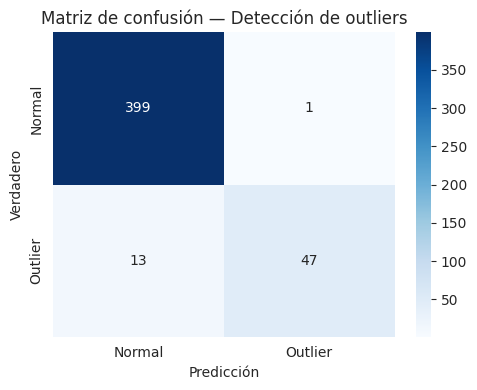

In [14]:
# Evaluar la detección de outliers
# Verdaderos positivos: outliers reales detectados como ruido
y_outlier_true = (y_anom == -1).astype(int)
y_outlier_pred = (db_anom.labels_ == -1).astype(int)

cm = confusion_matrix(y_outlier_true, y_outlier_pred)
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Detección de outliers con DBSCAN:")
print(f"  Verdaderos positivos (outliers detectados): {tp}")
print(f"  Falsos positivos (puntos normales marcados como outliers): {fp}")
print(f"  Falsos negativos (outliers no detectados): {fn}")
print(f"  Verdaderos negativos: {tn}")
print()
print(f"  Precisión: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  F1-score:  {f1:.3f}")

# Visualizar matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Outlier'],
            yticklabels=['Normal', 'Outlier'], ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Verdadero')
ax.set_title('Matriz de confusión — Detección de outliers')
plt.tight_layout(); plt.show()

## Conclusiones

1. **DBSCAN supera a K-means en datos con estructura no convexa.** En `make_moons` y `make_circles`, DBSCAN obtuvo ARI cercano a 1, mientras que K-means falló completamente porque divide los datos en regiones convexas que no respetan la geometría real de los clusters.

2. **K-means puede ser mejor en datos aproximadamente convexos.** En el dataset Iris, donde las clases son casi convexas, K-means obtuvo mejor ARI que DBSCAN. La estructura de densidad de Iris no separa bien `versicolor` y `virginica`.

3. **DBSCAN es excelente como detector de anomalías.** En el experimento de detección de outliers logramos un buen recall (la mayoría de outliers fueron identificados) sin necesidad de especificar reglas o thresholds explícitos.

4. **La elección de hiperparámetros es crucial.** Un `eps` mal elegido produce resultados absurdos (todo ruido o un solo cluster gigante). El gráfico de k-distancias es una herramienta práctica para guiar esta elección.

5. **Las métricas internas y externas son complementarias.** Las internas (Silhouette, Davies–Bouldin, Calinski–Harabasz) sirven cuando no hay etiquetas; las externas (ARI, NMI) son más informativas cuando se dispone de un ground truth.

6. **⚠️ Cuidado: las métricas internas pueden ser engañosas con clusters no convexos.** Como vimos en `circles`, DBSCAN logró ARI=1.0 (perfecto) pero peor Silhouette que K-means. Estas métricas internas asumen clusters compactos y aproximadamente convexos; cuando esa suposición se rompe (anillos, lunas, manifolds), prefiere métricas externas si tienes ground truth, o métricas basadas en densidad como `density-based clustering validation`.

7. **Limitaciones a tener presentes:** DBSCAN asume densidad globalmente homogénea. Cuando los clusters tienen densidades muy distintas, conviene usar variantes como **HDBSCAN** u **OPTICS**, que relajan esta suposición.

---

### Referencias

- Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.* KDD'96.
- Schubert, E., Sander, J., Ester, M., Kriegel, H. P., & Xu, X. (2017). *DBSCAN revisited, revisited: why and how you should (still) use DBSCAN.* ACM TODS, 42(3).
- scikit-learn documentation: <https://scikit-learn.org/stable/modules/clustering.html#dbscan>
- Pedregosa et al., *Scikit-learn: Machine Learning in Python*, JMLR 12, 2011.